In [15]:
import os
import sys
import re
import tqdm
from pathlib import Path
from dotenv import load_dotenv
import supervision as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

load_dotenv('.env')
DIR_SRC = os.getenv('DIR_SRC')
# dir_s2 = Path("out") / "study2"
# ls_meta = [f for f in dir_s2.iterdir() if f.suffix == '.csv' and f.name.startswith('results_')]
# data = pd.read_csv(ls_meta[0])
# for i in range(1, len(ls_meta)):
#     data_tmp = pd.read_csv(ls_meta[i])
#     data = pd.concat([data, data_tmp])

# # since the first two iterations of rtdetr-l are not comparable to the others, we remove them
# data = data.query("(model == 'rtdetr-l' and iters > 2) or (model != 'rtdetr-l')")
# data.loc[data['model'] == 'rtdetr-l', 'iters'] -= 2
# data = data.query("iters <= 6") 

# # add strategy category
# data["cat"] = "X"  # default category
# data.loc[data.is_finetune == "1_NOFT", "cat"] = "A_unfinetuned"
# data.loc[data.is_finetune == "2_FT", "cat"] = "B_finetuned_unsupervised"
# data.loc[data.metric == "map", "cat"] = "C_finetuned_supervised"
# data.to_csv("out/s2_raw.csv", index=False)

# order
strategy_order = [
    "bo_exploitation",
    "bo_exploration", 
    "grid_search", 
]
cat_order = [
    "A_unfinetuned",
    "B_finetuned_unsupervised",
    "C_finetuned_supervised"
]
model_order = ["yolo11n", "yolo11m", "rtdetr-l"]

In [13]:
data = pd.read_csv("out/s2_raw.csv")
data.head()

,model,n_params,is_finetune,thread,iters,time_per_epoch,max_mem,metric,strategy,time_hptuning,...,overlap,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp,cat
0,yolo11n,2.6,1_NOFT,5,1,4.630,6904.097,baseline,baseline,0.00,...,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,81966,81966,1697,A_unfinetuned
1,yolo11n,2.6,1_NOFT,5,1,4.630,6904.097,count,bo_exploration,4.57,...,0.62,0.4484,0.7770,0.8231,0.7243,0.7706,81966,22595,12763,A_unfinetuned
2,yolo11n,2.6,1_NOFT,5,1,4.630,6904.097,count,bo_exploitation,2.62,...,0.53,0.2534,0.5692,0.7000,0.4690,0.5617,81966,43524,16476,A_unfinetuned
3,yolo11n,2.6,1_NOFT,5,1,4.630,6904.097,count,grid_search,4.47,...,0.50,0.4484,0.7770,0.8231,0.7243,0.7706,81966,22595,12763,A_unfinetuned
4,yolo11n,2.6,2_FT,5,1,3.237,8293.878,baseline,baseline,0.00,...,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,81966,81966,697,B_finetuned_unsupervised


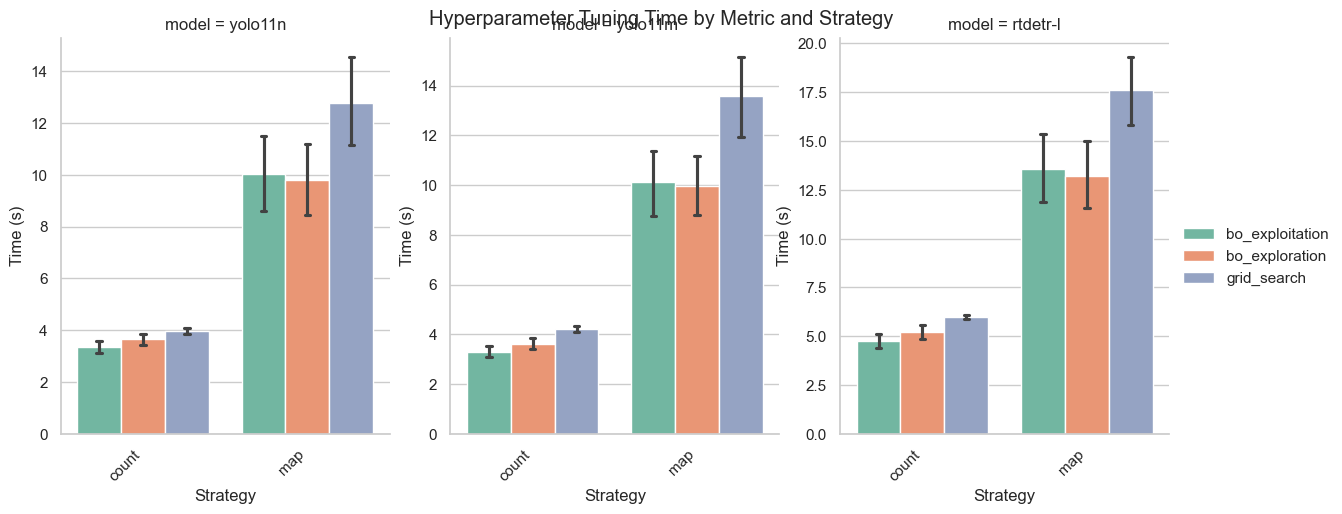

In [16]:
# box plot: x metric, hue: strategy, y time_hptuning
sns.set_theme(style="whitegrid")
data_hptime = data.query("metric != 'baseline' and time_hptuning < 40")

# col_facet by metric, x=strategy, y time_hptuning,
g = sns.FacetGrid(data_hptime, 
    col='model',
    sharey=False,
    height=5, aspect=.8)
g.map_dataframe(sns.barplot,
    x='metric', y='time_hptuning',
    hue='strategy', hue_order=strategy_order,
    width=0.8,
    # add caps to the error bars
    capsize=.1,
    palette="Set2",
    data=data_hptime)

g.add_legend()
g.fig.suptitle('Hyperparameter Tuning Time by Metric and Strategy')
for ax in g.axes.flat:
    ax.set_xlabel('Strategy')
    ax.set_ylabel('Time (s)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
g.savefig("out/s2_time_hptuning.png", dpi=300)

In [ ]:
# test hukey hsd between three groups
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

data_hptime_agg = data_hptime.groupby(['model', 'metric', 'strategy']).agg(
    time_hptuning_mean=('time_hptuning', 'mean'),
    time_hptuning_std=('time_hptuning', 'std'),
    time_hptuning_count=('time_hptuning', 'count')
).reset_index(inplace=False)
data_hptime_agg.to_csv("out/s2_time_hptuning.csv", index=False)

for m in model_order:
    for s in ["count", "map"]:
        print("model:", m, "opt-metric", s)
        data_tmp = data_hptime.query("model == @m and metric == @s")
        model = ols('time_hptuning ~ C(strategy)', data=data_tmp).fit()
        anova_results = anova_lm(model, typ=2)
        if anova_results['PR(>F)'][0] < 0.05:
            print("*")
            tukey = pairwise_tukeyhsd(data_tmp.loc[:, 'time_hptuning'].values, 
                                      data_tmp.loc[:, 'strategy'].values)
            # print(tukey)
            for group1, group2, pvalue in zip(tukey.groupsunique[:-1], tukey.groupsunique[1:], tukey.pvalues):
                if pvalue < 0.05:
                    print(f"{group1} vs {group2}: DIFFERENT!")
                else:
                    print(f"{group1} vs {group2}: SIMILAR")
        else:
            print("NS")

# yolo11n, count:  a, a, b
# yolo11n, map:    a, a, b
# yolo11m, count:  a, b, c
# yolo11m, map:    a, a, b    
# rtdetr-l, count: a, a, b
# rtdetr-l, map::  a, a, b

model: yolo11n opt-metric count
*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: yolo11n opt-metric map


*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: yolo11m opt-metric count
*


bo_exploitation vs bo_exploration: DIFFERENT!
bo_exploration vs grid_search: DIFFERENT!
model: yolo11m opt-metric map
*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: rtdetr-l opt-metric count
*


bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: rtdetr-l opt-metric map
*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!


In [20]:
# calculate mean, median, std, min, max
data_sum = data.\
    groupby(['model', "cat", "strategy"]).agg(
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
    # map50
    map50_mean=pd.NamedAgg(column='map50', aggfunc='mean'),
    map50_std=pd.NamedAgg(column='map50', aggfunc='std'),
    # precision
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    # recall
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
    # f1
    f1_mean=pd.NamedAgg(column='f1', aggfunc='mean'),
    f1_std=pd.NamedAgg(column='f1', aggfunc='std'),
    # time_hptuning'
    time_hptuning_mean=pd.NamedAgg(column='time_hptuning', aggfunc='mean'),
    time_hptuning_std=pd.NamedAgg(column='time_hptuning', aggfunc='std'),
    # time_inference
    time_inference_mean=pd.NamedAgg(column='time_inference', aggfunc='mean'),
    time_inference_std=pd.NamedAgg(column='time_inference', aggfunc='std'),
).reset_index()
data_sum.to_csv(Path("out") / "s2_pivot.csv", index=False)
data_sum

,model,cat,strategy,n_obs,map50_mean,map50_std,pre_mean,pre_std,rec_mean,rec_std,f1_mean,f1_std,time_hptuning_mean,time_hptuning_std,time_inference_mean,time_inference_std
0,rtdetr-l,A_unfinetuned,baseline,60,0.001285,0.001286,0.002647,0.002546,0.000260,0.000281,0.000482,0.000502,0.000000,0.000000,4.589167,0.511681
1,rtdetr-l,A_unfinetuned,bo_exploitation,55,0.534149,0.185324,0.648845,0.212349,0.514949,0.186080,0.572713,0.198045,5.112364,2.135931,63.093455,33.880537
2,rtdetr-l,A_unfinetuned,bo_exploration,55,0.557771,0.173944,0.668355,0.196552,0.545298,0.174036,0.599660,0.184710,5.093455,1.782158,70.372727,34.598183
3,rtdetr-l,A_unfinetuned,grid_search,55,0.643384,0.038711,0.754153,0.030997,0.644004,0.020987,0.694664,0.024581,6.006182,0.532845,112.406909,2.307492
4,rtdetr-l,B_finetuned_unsupervised,baseline,60,0.002358,0.003361,0.004763,0.006673,0.000513,0.000934,0.000917,0.001623,0.000000,0.000000,4.524667,0.537409
5,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,57,0.548493,0.208514,0.654195,0.230867,0.521586,0.203785,0.578221,0.216417,4.381579,1.787060,56.495965,33.690459
6,rtdetr-l,B_finetuned_unsupervised,bo_exploration,57,0.598212,0.167645,0.706493,0.179784,0.573626,0.160303,0.632119,0.169202,5.322632,1.986950,73.484561,33.708842
7,rtdetr-l,B_finetuned_unsupervised,grid_search,57,0.666502,0.063921,0.771035,0.047233,0.655802,0.037798,0.708684,0.041377,5.994386,0.535320,111.829298,3.098678
8,rtdetr-l,C_finetuned_supervised,bo_exploitation,53,0.593143,0.148137,0.705598,0.151047,0.561040,0.147192,0.623036,0.150711,13.584906,6.235404,47.286226,21.450118
9,rtdetr-l,C_finetuned_supervised,bo_exploration,55,0.626049,0.116667,0.731791,0.116943,0.601607,0.109442,0.659375,0.112737,13.228727,6.553924,45.421273,16.647073


In [18]:
data_fig = data.melt(id_vars=["model", "cat", "strategy", "divider", "overlap"], 
                     var_name="met", value_name="score")
data_fig = data_fig.query("met in ['precision', 'recall', 'f1', 'map50', 'time_inference']")
data_fig

,model,cat,strategy,divider,overlap,met,score
14816,yolo11n,A_unfinetuned,baseline,0.0,0.00,time_inference,4.53
14817,yolo11n,A_unfinetuned,bo_exploration,4.0,0.62,time_inference,73.69
14818,yolo11n,A_unfinetuned,bo_exploitation,2.0,0.53,time_inference,35.69
14819,yolo11n,A_unfinetuned,grid_search,4.0,0.50,time_inference,73.31
14820,yolo11n,B_finetuned_unsupervised,baseline,0.0,0.00,time_inference,2.89
...,...,...,...,...,...,...,...
25923,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,4.0,0.00,f1,0.6736
25924,rtdetr-l,B_finetuned_unsupervised,grid_search,4.0,0.50,f1,0.6855
25925,rtdetr-l,C_finetuned_supervised,bo_exploration,4.0,0.05,f1,0.6736
25926,rtdetr-l,C_finetuned_supervised,bo_exploitation,2.0,0.09,f1,0.4624


,model,cat,strategy,divider,overlap,met,score
18521,yolo11n,A_unfinetuned,bo_exploration,4.0,0.62,map50,0.777
18522,yolo11n,A_unfinetuned,bo_exploitation,2.0,0.53,map50,0.5692
18523,yolo11n,A_unfinetuned,grid_search,4.0,0.50,map50,0.777
18525,yolo11n,B_finetuned_unsupervised,bo_exploration,3.0,0.34,map50,0.755
18526,yolo11n,B_finetuned_unsupervised,bo_exploitation,2.0,0.62,map50,0.6046
...,...,...,...,...,...,...,...
20367,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,4.0,0.00,map50,0.6312
20368,rtdetr-l,B_finetuned_unsupervised,grid_search,4.0,0.50,map50,0.6358
20369,rtdetr-l,C_finetuned_supervised,bo_exploration,4.0,0.05,map50,0.6312
20370,rtdetr-l,C_finetuned_supervised,bo_exploitation,2.0,0.09,map50,0.4363


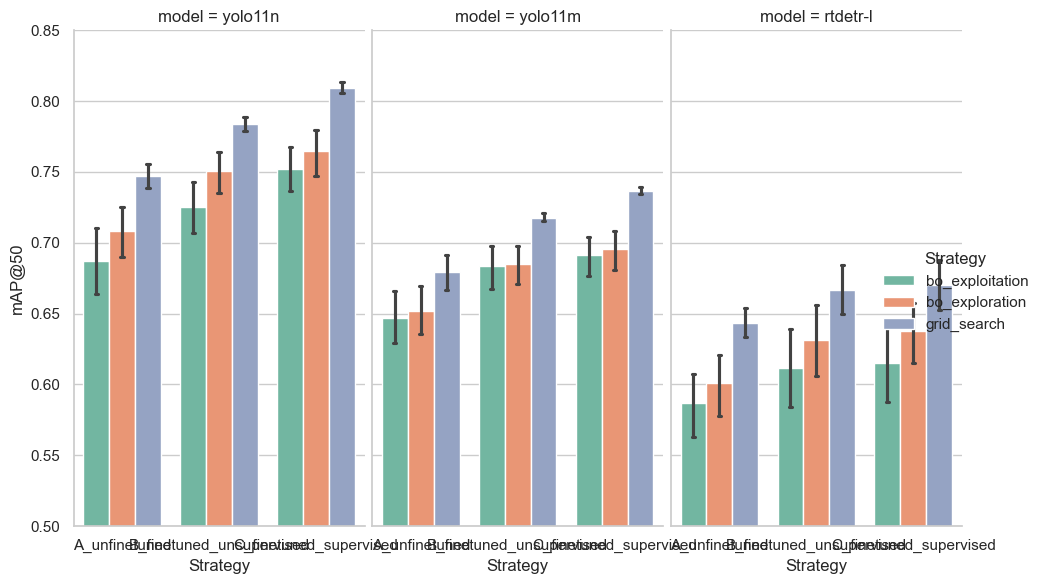

In [33]:
sns.set_theme(style="whitegrid")

# set cat order for data_fig
data_fig["cat"] = pd.Categorical(data_fig["cat"], categories=cat_order, ordered=True)
data_fig_filter = data_fig.query("met == 'map50' and\
        strategy != 'baseline' and\
        score > 0.2")
g = sns.FacetGrid(
    data_fig_filter,
    col="model",
    col_order=model_order,
    sharey=True,
    height=6, aspect=1.2,
)
g.map_dataframe(sns.barplot, 
    data=data_fig_filter,
    x="cat", y="score", 
    hue="strategy", hue_order=strategy_order,
    capsize=.1,
    palette="Set2",
    )
# title
g.add_legend(title="Strategy")
g.set(
    ylim=(.5, .85),
    xlabel="Strategy",
    ylabel="mAP@50",
)
# # set x label 45 degrees
# g.set_titles(col_template="{col_name}")
# g.set_xticklabels(rotation=45)
# g.figure.subplots_adjust(right=1.2)
g.figure.set_size_inches(10, 6)
g.savefig(Path("out") / "s2_results.png", dpi=300)

data_fig_filter.to_csv(Path("out") / "s2_figure.csv", index=False)
data_fig.query("score > 0.2 and strategy != 'baseline'").pivot_table(
    index=["model", "cat", "strategy"], 
    columns="met", 
    values="score", 
    aggfunc=["mean", "std"]
).reset_index().to_csv(
    Path("out") / "s2_figure.csv", index=False
)
data_fig.query("met == 'map50' and\
        strategy != 'baseline' and\
        score > 0.2")

In [ ]:
import numpy as np
x = np.array([26.6, 66.3, 40.0, 30.2, 47.6, 24.5, 28.4, 17.3])
x /= 60
fps = 1 / x
print("FPS:", fps.round(2))

FPS: [0.38 0.15 0.25 0.33 0.21 0.41 0.35 0.58]


In [11]:
import pandas as pd
import os
os.getcwd()
data_fig = pd.read_csv("out/s2_results.csv").query("strategy != 'baseline' and met in ['map50', 'f1', 'precision', 'recall']")
data_fig.pivot_table(
    index=["model", "cat", "strategy"], 
    columns="met", 
    values="score", 
    aggfunc=['mean', 'std', 'count']
).reset_index()

model                       cat         strategy      mean            \
met                                                             f1     map50   
0    rtdetr-l             A_unfinetuned  bo_exploitation  0.572713  0.534149   
1    rtdetr-l             A_unfinetuned   bo_exploration  0.599660  0.557771   
2    rtdetr-l             A_unfinetuned      grid_search  0.694664  0.643384   
3    rtdetr-l  B_finetuned_unsupervised  bo_exploitation  0.578221  0.548493   
4    rtdetr-l  B_finetuned_unsupervised   bo_exploration  0.632119  0.598212   
5    rtdetr-l  B_finetuned_unsupervised      grid_search  0.708684  0.666502   
6    rtdetr-l    C_finetuned_supervised  bo_exploitation  0.623036  0.593143   
7    rtdetr-l    C_finetuned_supervised   bo_exploration  0.659375  0.626049   
8    rtdetr-l    C_finetuned_supervised      grid_search  0.704991  0.670319   
9     yolo11m             A_unfinetuned  bo_exploitation  0.587456  0.567467   
10    yolo11m             A_unfinetuned   bo_exploration  0.666279  0.640811   
11    yolo11m             A_unfinetuned      grid_search  0.708640  0.679547   
12    yolo11m  B_finetuned_unsupervised  bo_exploitation  0.614450  0.604224   
13    yolo11m  B_finetuned_unsupervised   bo_exploration  0.641203  0.629276   
14    yolo11m  B_finetuned_unsupervised      grid_search  0.732521  0.717731   
15    yolo11m    C_finetuned_supervised  bo_exploitation  0.676285  0.666408   
16    yolo11m    C_finetuned_supervised   bo_exploration  0.694102  0.682694   
17    yolo11m    C_finetuned_supervised      grid_search  0.744392  0.736509   
18    yolo11n             A_unfinetuned  bo_exploitation  0.642521  0.639912   
19    yolo11n             A_unfinetuned   bo_exploration  0.700018  0.696519   
20    yolo11n             A_unfinetuned      grid_search  0.753821  0.747172   
21    yolo11n  B_finetuned_unsupervised  bo_exploitation  0.649754  0.664420   
22    yolo11n  B_finetuned_unsupervised   bo_exploration  0.713120  0.724437   
23    yolo11n  B_finetuned_unsupervised      grid_search  0.774266  0.783813   
24    yolo11n    C_finetuned_supervised  bo_exploitation  0.737102  0.752035   
25    yolo11n    C_finetuned_supervised   bo_exploration  0.693108  0.708940   
26    yolo11n    C_finetuned_supervised      grid_search  0.792359  0.809584   

                              std                               count        \
met precision    recall        f1     map50 precision    recall    f1 map50   
0    0.648845  0.514949  0.198045  0.185324  0.212349  0.186080    55    55   
1    0.668355  0.545298  0.184710  0.173944  0.196552  0.174036    55    55   
2    0.754153  0.644004  0.024581  0.038711  0.030997  0.020987    55    55   
3    0.654195  0.521586  0.216417  0.208514  0.230867  0.203785    57    57   
4    0.706493  0.573626  0.169202  0.167645  0.179784  0.160303    57    57   
5    0.771035  0.655802  0.041377  0.063921  0.047233  0.037798    57    57   
6    0.705598  0.561040  0.150711  0.148137  0.151047  0.147192    53    53   
7    0.731791  0.601607  0.112737  0.116667  0.116943  0.109442    55    55   
8    0.771377  0.649264  0.041967  0.064935  0.048550  0.037849    53    53   
9    0.652375  0.537016  0.228365  0.219753  0.240811  0.213340    55    55   
10   0.731530  0.613009  0.104257  0.106320  0.104786  0.102898    57    57   
11   0.765969  0.659589  0.029432  0.048771  0.036805  0.026729    55    55   
12   0.693283  0.556412  0.230850  0.222499  0.241554  0.216963    58    58   
13   0.718759  0.582427  0.199526  0.191949  0.206780  0.188625    59    59   
14   0.798374  0.676712  0.007232  0.011112  0.008914  0.006610    58    58   
15   0.754983  0.616189  0.143223  0.137910  0.142336  0.142432    53    53   
16   0.766883  0.636413  0.108053  0.105671  0.104826  0.110515    54    54   
17   0.803906  0.693117  0.007090  0.010782  0.008476  0.006965    53    53   
18   0.725479  0.579237  0.193201  0.191076  0.200945  0.182726    57    57   
19   0.780379  0.637728  0.1

In [22]:
for m in model_order:
    print("model:", m)
    data_tmp = data_fig.query("model == @m and\
        met == 'map50' and\
            strategy == 'grid_search'")
    data_tmp['score'] = data_tmp['score'].astype(float)
    model = ols('score ~ C(cat)', data=data_tmp).fit()
    anova_results = anova_lm(model, typ=2)
    if anova_results['PR(>F)'][0] < 0.05:
        print("*")
        tukey = pairwise_tukeyhsd(data_tmp.loc[:, 'score'].values, 
                                  data_tmp.loc[:, 'cat'].values)
        print(tukey)
        for group1, group2, pvalue in zip(tukey.groupsunique[:-1], tukey.groupsunique[1:], tukey.pvalues):
            if pvalue < 0.05:
                print(f"{group1} vs {group2}: DIFFERENT!")
            else:
                print(f"{group1} vs {group2}: SIMILAR")
    else:
        print("NS")
# yolo11n: a, b, c
# yolo11m: a, b, c
# rtdetr-l: a, ab, b
            

model: yolo11n
*
                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
         group1                   group2          meandiff p-adj lower  upper  reject
-------------------------------------------------------------------------------------
           A_unfinetuned B_finetuned_unsupervised   0.0366   0.0 0.0256 0.0477   True
           A_unfinetuned   C_finetuned_supervised   0.0624   0.0 0.0511 0.0737   True
B_finetuned_unsupervised   C_finetuned_supervised   0.0258   0.0 0.0144 0.0371   True
-------------------------------------------------------------------------------------
A_unfinetuned vs B_finetuned_unsupervised: DIFFERENT!
B_finetuned_unsupervised vs C_finetuned_supervised: DIFFERENT!
model: yolo11m
*


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                   group2          meandiff p-adj  lower  upper  reject
--------------------------------------------------------------------------------------
           A_unfinetuned B_finetuned_unsupervised   0.0382    0.0 0.0251 0.0513   True
           A_unfinetuned   C_finetuned_supervised    0.057    0.0 0.0435 0.0704   True
B_finetuned_unsupervised   C_finetuned_supervised   0.0188 0.0028 0.0055  0.032   True
--------------------------------------------------------------------------------------
A_unfinetuned vs B_finetuned_unsupervised: DIFFERENT!
B_finetuned_unsupervised vs C_finetuned_supervised: DIFFERENT!
model: rtdetr-l
*
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                   group2          meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------------------

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [4]:
import pandas as pd
import numpy as np
data_fig = pd.read_csv("out/s2_results.csv")
data_grid_all = data_fig.query("met in ['map50', 'time_inference']").\
                   query("strategy != 'baseline'").\
                       query("cat != 'A_unfinetuned'").\
                          query("model == 'yolo11n'")
# -0.125, 0.125 -> 0
# 0.125, 0.375 -> 0.25
# 0.375, 0.625 -> 0.5
def convert_overlap(overlap):
    if overlap < 0.125:
        return 0
    elif overlap < 0.375:
        return 0.25
    elif overlap < 0.625:
        return 0.5
def convert_divider(divider):
    return round(divider)
data_grid_all['overlap_cat'] = data_grid_all['overlap'].apply(convert_overlap)
data_grid_all['divider_cat'] = data_grid_all['divider'].apply(convert_divider)
data_grid_all


,model,cat,strategy,divider,overlap,met,score,overlap_cat,divider_cat
5,yolo11n,B_finetuned_unsupervised,bo_exploration,3.0,0.34,time_inference,30.0000,0.25,3
6,yolo11n,B_finetuned_unsupervised,bo_exploitation,2.0,0.62,time_inference,32.3900,0.50,2
7,yolo11n,B_finetuned_unsupervised,grid_search,4.0,0.50,time_inference,66.3000,0.50,4
8,yolo11n,C_finetuned_supervised,bo_exploration,4.0,-0.12,time_inference,26.6100,0.00,4
9,yolo11n,C_finetuned_supervised,bo_exploitation,3.0,0.29,time_inference,29.6400,0.25,3
...,...,...,...,...,...,...,...,...,...
3655,yolo11n,B_finetuned_unsupervised,bo_exploitation,3.0,0.52,map50,0.7523,0.50,3
3656,yolo11n,B_finetuned_unsupervised,grid_search,4.0,0.50,map50,0.7937,0.50,4
3657,yolo11n,C_finetuned_supervised,bo_exploration,3.0,-0.05,map50,0.7478,0.00,3
3658,yolo11n,C_finetuned_supervised,bo_exploitation,3.0,0.35,map50,0.7554,0.25,3


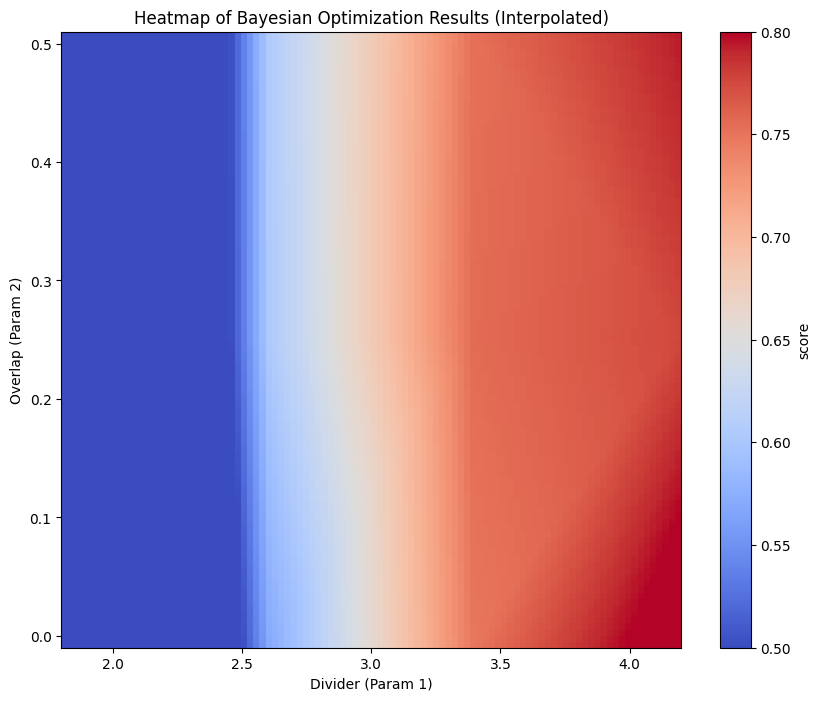

In [7]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

def plot_hpmap(data_grid, crange=(0.6, 0.9), x_jitter=.03):
    # Prepare data for interpolation
    x = data_grid["divider_cat"].values
    y = data_grid["overlap_cat"].values
    z = data_grid["score"].values
    s = data_grid["strategy"].values

    # Create a regular grid for interpolation
    grid_x, grid_y = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]

    # Interpolate the data
    grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

    # Plotting the heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(
        grid_z.T,
        # extent=(min(x), max(x), min(y), max(y)),
        extent=(1.8, 4.2, -0.01, 0.51),
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
    )
    plt.colorbar(label="score")
    # set uplimits of hue
    plt.clim(*crange)
    plt.xlabel("Divider (Param 1)")
    plt.ylabel("Overlap (Param 2)")
    plt.title("Heatmap of Bayesian Optimization Results (Interpolated)")
    
    # df_b = data_grid[data_grid["cat"] == "B_finetuned_unsupervised"]
    # df_b = data_grid[data_grid["strategy"] == "grid_search"]
    # df_b = df_b.sort_values(by="score", ascending=False)
    # # print(df_b)
    # df_c = data_grid[data_grid["cat"] == "C_finetuned_supervised"]
    # df_c = data_grid[data_grid["strategy"] == "grid_search"]
    # df_c = df_c.sort_values(by="score", ascending=False)
    # # print(df_c)
    # plt.scatter(df_b["divider"] + x_jitter, df_b["overlap"],
    #             color="blue", marker="o", label="bo_exploration", s=100, edgecolors='black')
    # plt.scatter(df_c["divider"] - x_jitter, df_c["overlap"],
    #             color="white", marker="X", label="grid_search", s=100, edgecolors='black')
    # plt.legend()
    return plt, grid_z
plot, grid_map = plot_hpmap(data_grid_all.query("met == 'map50' and model == 'yolo11n'"), (0.5, 0.80))
plot.savefig("out/s2_hpmap_map50.png", dpi=300)


In [9]:
data_grid_all.query("model == 'yolo11n' and cat == 'C_finetuned_supervised' and met == 'map50'").\
    groupby(["strategy", "overlap_cat", "divider_cat"]).agg(
    n_obs=pd.NamedAgg(column='score', aggfunc='count'),
    score_mean=pd.NamedAgg(column='score', aggfunc='mean'),
    score_std=pd.NamedAgg(column='score', aggfunc='std'),
).reset_index(inplace=False).dropna().\
    pivot(index=["overlap_cat", "divider_cat"], 
          columns="strategy", 
          values=["n_obs", "score_mean", "score_std"]).\
    reset_index(inplace=False).to_csv("out/s2_hpmap.csv", index=False)

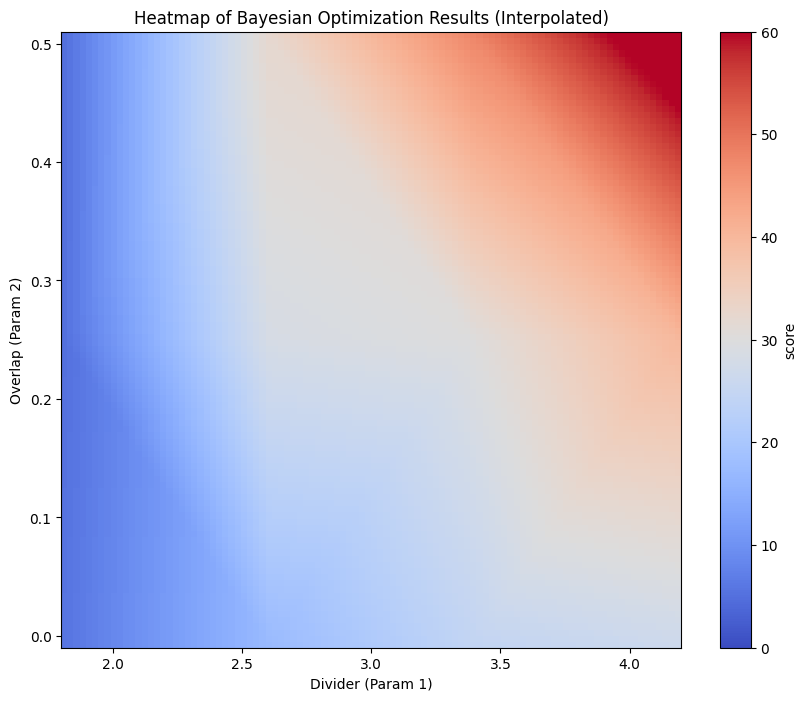

In [12]:
plot, grid_time = plot_hpmap(data_grid_all.query("met == 'time_inference' and model == 'yolo11n'"), (0, 60))
plot.savefig("out/s2_hpmap_infer.png", dpi=300)

In [20]:
ls_grid = []
ls_overlap = []
ls_map = []
ls_time = []
for i in [1, 2, 3, 4]:
    for j in [0, 0.25, 0.5]:
        # 1-> 0, 2-> 33, 3-> 66, 4-> 100
        idx_i = int((i - 1) * 100 / 3)
        idx_j = int(j * 100 * 2)
        idx_i = min(idx_i, grid_map.shape[0] - 1)
        idx_j = min(idx_j, grid_map.shape[1] - 1)
        ls_grid.append(i)
        ls_overlap.append(j)
        ls_map.append(grid_map[idx_i, idx_j])
        ls_time.append(grid_time[idx_i, idx_j])
df_grid = pd.DataFrame({
    "divider": ls_grid,
    "overlap": ls_overlap,
    "map50": ls_map,
    "time_inference": ls_time
})
df_grid.to_csv("out/s2_hpmap_exp.csv", index=False)